In [ ]:
!pip install medmnist -q

In [2]:
from medmnist import DermaMNIST

# Descarga automáticamente
train_dataset = DermaMNIST(split='train', download=True)
val_dataset = DermaMNIST(split='val', download=True)
test_dataset = DermaMNIST(split='test', download=True)

print(len(train_dataset))

7007


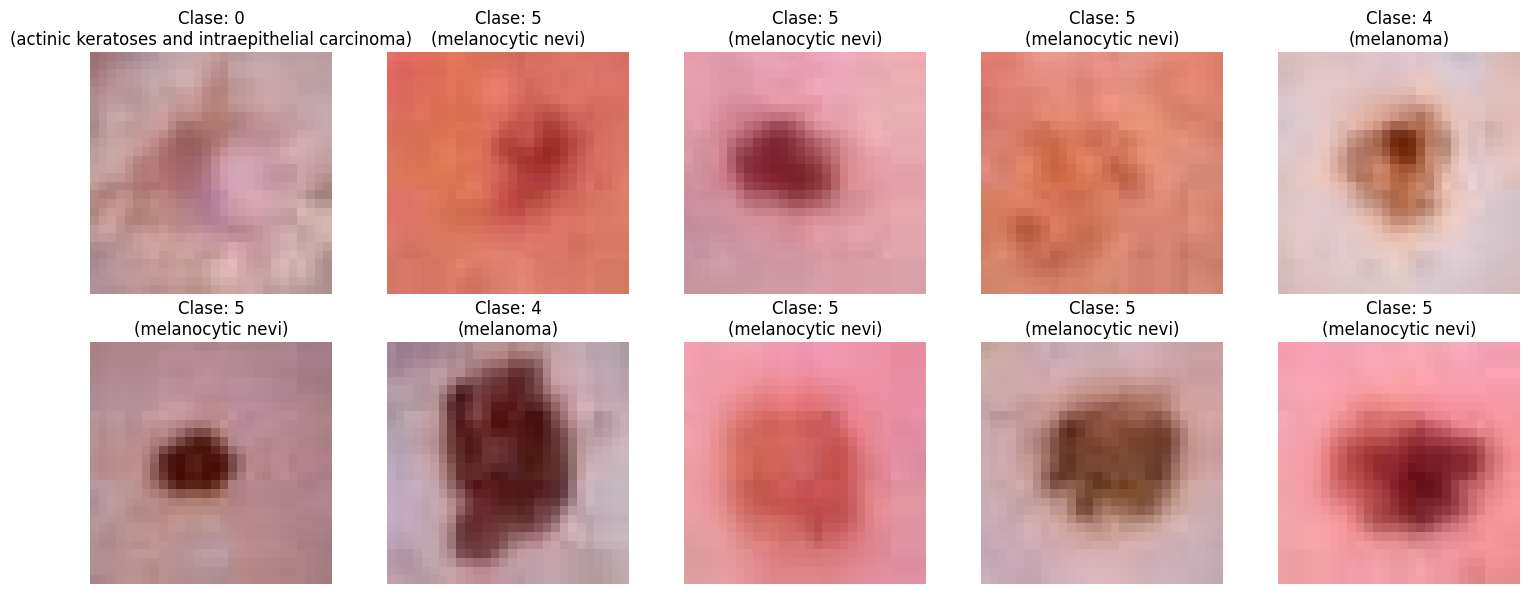

In [3]:
import matplotlib.pyplot as plt

# MedMNIST guarda la metadata del dataset, incluyendo los nombres de las clases
class_dict = train_dataset.info['label']

# Creamos una cuadrícula de 2 filas y 5 columnas
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flatten()):
    # train_dataset[i] devuelve una tupla: (Imagen PIL, Array de la etiqueta)
    img, label = train_dataset[i]
    label_idx = label[0] # Extraemos el número de la etiqueta
    class_name = class_dict[str(label_idx)] # Buscamos el nombre de la enfermedad

    ax.imshow(img)
    ax.set_title(f"Clase: {label_idx}\n({class_name})")
    ax.axis('off')

plt.tight_layout()
plt.show()

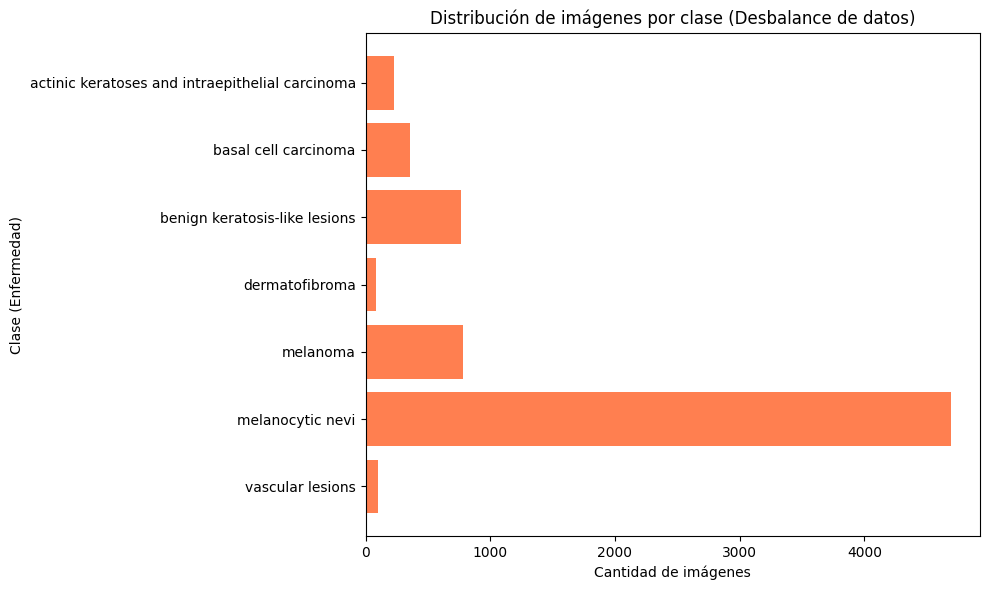

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Aseguramos que class_dict esté definido
class_dict = train_dataset.info['label']

# Extraemos todas las etiquetas del dataset de entrenamiento
labels = [label[0] for img, label in train_dataset]

# Contamos cuántas imágenes hay por clase
clases_unicas, conteos = np.unique(labels, return_counts=True)
nombres_clases = [class_dict[str(c)] for c in clases_unicas]

# Graficamos el desbalance de forma horizontal para manejar nombres largos
plt.figure(figsize=(10, 6))
plt.barh(nombres_clases, conteos, color='coral')
plt.title('Distribución de imágenes por clase (Desbalance de datos)')
plt.xlabel('Cantidad de imágenes')
plt.ylabel('Clase (Enfermedad)')
plt.gca().invert_yaxis() # Mantiene el orden original de las clases de arriba a abajo
plt.tight_layout()
plt.show()

In [5]:
print(conteos)
print(nombres_clases)

[ 228  359  769   80  779 4693   99]
['actinic keratoses and intraepithelial carcinoma', 'basal cell carcinoma', 'benign keratosis-like lesions', 'dermatofibroma', 'melanoma', 'melanocytic nevi', 'vascular lesions']


In [6]:
import pandas as pd

# Obtenemos la información de las etiquetas del dataset
info = train_dataset.info
labels = info['label']

# Creamos un DataFrame para visualizarlo de forma ordenada
categories_df = pd.DataFrame(list(labels.items()), columns=['ID', 'Categoría'])

print("Categorías disponibles en DermaMNIST:")
display(categories_df)

Categorías disponibles en DermaMNIST:


,ID,Categoría
0,0,actinic keratoses and intraepithelial carcinoma
1,1,basal cell carcinoma
2,2,benign keratosis-like lesions
3,3,dermatofibroma
4,4,melanoma
5,5,melanocytic nevi
6,6,vascular lesions


In [7]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from medmnist import DermaMNIST

# 1. Definimos una transformación básica: convertir las imágenes a tensores
data_transform = transforms.Compose([
    transforms.ToTensor()
])

# 2. Volvemos a cargar los datasets, pero ahora aplicando la transformación
train_dataset = DermaMNIST(split='train', transform=data_transform, download=True)
val_dataset = DermaMNIST(split='val', transform=data_transform, download=True)
test_dataset = DermaMNIST(split='test', transform=data_transform, download=True)

# 3. Creamos los DataLoaders (empaquetan los datos en lotes, ej: de 32 en 32 imágenes)
# Solo mezclamos (shuffle=True) los datos de entrenamiento
BATCH_SIZE = 32
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Lotes de entrenamiento: {len(train_loader)}")
print(f"Lotes de validación: {len(val_loader)}")
print(f"Lotes de prueba: {len(test_loader)}")

Lotes de entrenamiento: 219
Lotes de validación: 32
Lotes de prueba: 63


In [8]:
# Obtenemos un lote de prueba del DataLoader de entrenamiento
imagenes_prueba, etiquetas_prueba = next(iter(train_loader))

# Imprimimos la forma del tensor de las imágenes
print(f"Forma del lote (Batch shape): {imagenes_prueba.shape}")

# Explicación de la salida:
# El formato en PyTorch es [Batch_size, Canales, Alto, Ancho]
# Debería imprimir: torch.Size([32, 3, 28, 28])
# Esto confirma que estamos procesando 32 imágenes por lote, a color (3 canales RGB), de 28x28 píxeles.

Forma del lote (Batch shape): torch.Size([32, 3, 28, 28])


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

# Configurar el dispositivo (GPU si está disponible, si no CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# 1. Cargar la arquitectura ResNet18 con pesos PRE-ENTRENADOS (Fine-Tuning)
# Usamos los pesos de ImageNet que es el estándar de la industria
modelo = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 2. Modificar la última capa (Clasificador)
# ResNet viene configurado para 1000 clases. DermaMNIST tiene 7.
# Al cambiar esta capa, sus pesos se inicializan desde cero,
# mientras el resto de la red mantiene el conocimiento previo.
num_features = modelo.fc.in_features
modelo.fc = nn.Linear(num_features, 7)

# Enviar el modelo a la tarjeta gráfica o procesador
modelo = modelo.to(device)

# 3. Definir Función de Pérdida y Optimizador
criterio = nn.CrossEntropyLoss()
# Usamos un learning rate pequeño (0.001) típico en fine-tuning para no destruir los pesos pre-entrenados
optimizador = optim.Adam(modelo.parameters(), lr=0.001)

Usando dispositivo: cpu


In [ ]:
import time

# Definimos pocas épocas para establecer el baseline rápido
num_epocas = 10

# Historial del baseline para graficar después
historial_train_loss_baseline = []
historial_val_loss_baseline = []
historial_train_acc_baseline = []
historial_val_acc_baseline = []

for epoca in range(num_epocas):
    inicio_tiempo = time.time()

    # ==========================
    # FASE DE ENTRENAMIENTO
    # ==========================
    modelo.train() # Ponemos el modelo en modo entrenamiento
    train_loss = 0.0
    train_correctos = 0
    total_train = 0

    for inputs, labels in train_loader: # Asumiendo que ya creaste train_loader
        inputs, labels = inputs.to(device), labels.squeeze().to(device)

        # 1. Reiniciar los gradientes
        optimizador.zero_grad()

        # 2. Propagación hacia adelante (Forward)
        outputs = modelo(inputs)
        loss = criterio(outputs, labels)

        # 3. Propagación hacia atrás y optimización (Backward & Step)
        loss.backward()
        optimizador.step()

        # Calcular estadísticas
        train_loss += loss.item() * inputs.size(0)
        _, predicciones = torch.max(outputs, 1)
        train_correctos += torch.sum(predicciones == labels.data)
        total_train += labels.size(0)

    acc_train = train_correctos.double() / total_train

    # ==========================
    # FASE DE VALIDACIÓN
    # ==========================
    modelo.eval() # Ponemos el modelo en modo evaluación (apaga el Dropout, etc.)
    val_loss = 0.0
    val_correctos = 0
    total_val = 0

    # No calculamos gradientes en validación (ahorra memoria y tiempo)
    with torch.no_grad():
        for inputs, labels in val_loader: # Asumiendo que ya creaste val_loader
            inputs, labels = inputs.to(device), labels.squeeze().to(device)

            outputs = modelo(inputs)
            loss = criterio(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicciones = torch.max(outputs, 1)
            val_correctos += torch.sum(predicciones == labels.data)
            total_val += labels.size(0)

    acc_val = val_correctos.double() / total_val
    tiempo_epoca = time.time() - inicio_tiempo

    # Guardar métricas de esta época en el historial
    historial_train_loss_baseline.append(train_loss / total_train)
    historial_val_loss_baseline.append(val_loss / total_val)
    historial_train_acc_baseline.append(acc_train.item())
    historial_val_acc_baseline.append(acc_val.item())

    # Imprimir resultados de la época
    print(f'Época {epoca+1}/{num_epocas} | Tiempo: {tiempo_epoca:.0f}s')
    print(f'Train Loss: {train_loss/total_train:.4f} | Train Acc: {acc_train:.4f}')
    print(f'Val Loss: {val_loss/total_val:.4f} | Val Acc: {acc_val:.4f}')
    print('-' * 40)

print("¡Entrenamiento del baseline completado!")

In [ ]:
# ==========================================
# GRÁFICO LOSS / ACCURACY - BASELINE (ResNet18)
# ==========================================
# Usamos el historial que se llenó durante el entrenamiento del baseline (celda anterior).
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Modelo: Baseline CNN (ResNet18)', fontsize=14, fontweight='bold')

# Gráfico de Función de Pérdida (Loss)
ax1.plot(historial_train_loss_baseline, label='Entrenamiento', color='blue', marker='o')
ax1.plot(historial_val_loss_baseline, label='Validación', color='red', marker='o')
ax1.set_title('Evolución de la Función de Pérdida (Loss)')
ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida')
ax1.legend()
ax1.grid(True)

# Gráfico de Exactitud (Accuracy)
ax2.plot(historial_train_acc_baseline, label='Entrenamiento', color='blue', marker='o')
ax2.plot(historial_val_acc_baseline, label='Validación', color='red', marker='o')
ax2.set_title('Evolución de la Exactitud (Accuracy)')
ax2.set_xlabel('Época')
ax2.set_ylabel('Exactitud')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Implementación de un modelo CNN-Transformer (Visión Transformer)

Para un enfoque más avanzado, podemos combinar la capacidad de extracción de características locales de una CNN con la habilidad de un Transformer para modelar dependencias a largo plazo y relaciones globales entre estas características. Esto es similar al concepto de Vision Transformers (ViT).

Dado que DermaMNIST típicamente trabaja con imágenes de 28x28 píxeles, para trabajar con 128x128 píxeles, aplicaremos una transformación de redimensionamiento a las imágenes.

In [12]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from medmnist import DermaMNIST
import torch.nn as nn
import torchvision.models as models

# 1. Definimos transformaciones:
#    - Para el entrenamiento: Incluir aumentación de datos para reducir el overfitting.
#    - Para validación/prueba: Solo redimensionar y convertir a tensor (sin aumentación).

train_transform_128 = transforms.Compose([
    transforms.Resize((128, 128)), # Redimensionar a 128x128
    transforms.RandomHorizontalFlip(), # Volteo horizontal aleatorio
    transforms.RandomRotation(15),     # Rotación aleatoria de hasta 15 grados
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1), # Ajustes de color
    transforms.ToTensor()
])

val_test_transform_128 = transforms.Compose([
    transforms.Resize((128, 128)), # Redimensionar a 128x128
    transforms.ToTensor()
])

# 2. Volvemos a cargar los datasets, aplicando las transformaciones adecuadas
train_dataset_128 = DermaMNIST(split='train', transform=train_transform_128, download=True)
val_dataset_128 = DermaMNIST(split='val', transform=val_test_transform_128, download=True)
test_dataset_128 = DermaMNIST(split='test', transform=val_test_transform_128, download=True)

# 3. Creamos los DataLoaders con el nuevo tamaño de imagen
BATCH_SIZE = 32 # Mantendremos el mismo tamaño de lote
train_loader_128 = DataLoader(dataset=train_dataset_128, batch_size=BATCH_SIZE, shuffle=True)
val_loader_128 = DataLoader(dataset=val_dataset_128, batch_size=BATCH_SIZE, shuffle=False)
test_loader_128 = DataLoader(dataset=test_dataset_128, batch_size=BATCH_SIZE, shuffle=False)

print(f"Lotes de entrenamiento (128x128): {len(train_loader_128)}")
print(f"Lotes de validación (128x128): {len(val_loader_128)}")
print(f"Lotes de prueba (128x128): {len(test_loader_128)}")

# Obtenemos un lote de prueba para verificar la forma
imagenes_prueba_128, etiquetas_prueba_128 = next(iter(train_loader_128))
print(f"Forma del lote (Batch shape) 128x128: {imagenes_prueba_128.shape}")

Lotes de entrenamiento (128x128): 219
Lotes de validación (128x128): 32
Lotes de prueba (128x128): 63
Forma del lote (Batch shape) 128x128: torch.Size([32, 3, 128, 128])


### Definición del Modelo CNN-Transformer

Este modelo utilizará una ResNet pre-entrenada para extraer características de las imágenes. Luego, las características se "parcharán" y se alimentarán a un Transformer Encoder, similar a cómo funciona un Vision Transformer.

In [14]:
class CNNTransformerClassifier(nn.Module):
    def __init__(self, num_classes=7, embed_dim=512, num_heads=8, num_layers=4, dropout=0.1):
        super().__init__()

        # Backbone CNN: Usamos ResNet18 pre-entrenada como extractor de características
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        # Eliminamos la capa de clasificación final (fc) de ResNet
        self.cnn_backbone = nn.Sequential(*list(resnet.children())[:-2])

        # El tamaño de la salida del último bloque convolucional de ResNet18
        # para una imagen de 128x128 será (batch_size, 512, 4, 4).
        # Queremos aplanar esto en una secuencia de tokens.
        # num_patches = H * W = 4 * 4 = 16
        # embed_dim = C = 512
        self.num_patches = 4 * 4  # Esto asume una salida 4x4 del CNN para 128x128

        # Proyección lineal para asegurar que las características tengan el embed_dim correcto
        # (aunque en ResNet18 la última capa conv ya produce 512 canales)
        # self.projection = nn.Linear(512, embed_dim) # Podría ser útil si el embed_dim cambia

        # Embeddings posicionales: aprendibles
        self.positional_embedding = nn.Parameter(torch.randn(1, self.num_patches, embed_dim))

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Clasificador final (capa MLP head)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        # 1. Pasa la imagen a través del backbone CNN
        # Entrada: (B, 3, 128, 128)
        # Salida del CNN: (B, 512, 4, 4) (ejemplo para ResNet18)
        x = self.cnn_backbone(x)

        # 2. "Parchar" las características: Aplanar HxW a una secuencia
        # De (B, C, H, W) a (B, H*W, C)
        # (B, 512, 4, 4) -> (B, 16, 512)
        x = x.flatten(2) # Aplanar las dimensiones H y W
        x = x.permute(0, 2, 1) # Cambiar a (B, num_patches, embed_dim)

        # 3. Añadir embeddings posicionales
        x = x + self.positional_embedding

        # 4. Pasar por el Transformer Encoder
        # El Transformer espera (Seq_len, Batch, Feature_dim), así que transponemos
        x = self.transformer_encoder(x.transpose(0, 1))

        # 5. Tomar la salida del "token de clase" o hacer un pooling (promedio) de los tokens
        # Aquí usaremos el promedio de todos los tokens de la secuencia para la clasificación.
        # La salida del transformer es (Seq_len, Batch, Feature_dim), lo convertimos a (Batch, Feature_dim)
        x = x.mean(dim=0) # Promedio a lo largo de la dimensión de la secuencia

        # 6. Clasificador final
        logits = self.classifier(x)
        return logits

# Configurar el dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo para CNN-Transformer: {device}")

Usando dispositivo para CNN-Transformer: cpu


### Inicialización y Entrenamiento del Modelo CNN-Transformer

In [17]:
import torch.optim as optim
import time

# Instanciar el modelo CNN-Transformer
model_cnn_transformer = CNNTransformerClassifier(num_classes=7, embed_dim=512, num_heads=8, num_layers=4, dropout=0.1).to(device)

# Definir Función de Pérdida y Optimizador
criterion_cnn_transformer = nn.CrossEntropyLoss()
# Añadimos weight_decay para L2 regularization (comúnmente 1e-4 o 1e-5)
optimizer_cnn_transformer = optim.Adam(model_cnn_transformer.parameters(), lr=0.0001, weight_decay=1e-4)

# Definir el número de épocas
num_epochs_cnn_transformer = 20 # Aumentamos las épocas para permitir que el early stopping actúe

# ========================== EARLY STOPPING ==========================
# Inicialización para Early Stopping
best_val_loss = float('inf')
patience = 5 # Cuántas épocas esperar si no hay mejora
trigger_times = 0 # Contador para las épocas sin mejora

# Listas para guardar el historial de métricas para graficar
historial_train_loss_cnn_transformer = []
historial_val_loss_cnn_transformer = []
historial_train_acc_cnn_transformer = []
historial_val_acc_cnn_transformer = []

print("Comenzando el entrenamiento del modelo CNN-Transformer...")

for epoch in range(num_epochs_cnn_transformer):
    start_time = time.time()

    # ========================== FASE DE ENTRENAMIENTO ==========================
    model_cnn_transformer.train()
    train_loss = 0.0
    train_corrects = 0
    total_train = 0

    for inputs, labels in train_loader_128:
        inputs, labels = inputs.to(device), labels.squeeze().to(device)

        optimizer_cnn_transformer.zero_grad()
        outputs = model_cnn_transformer(inputs)
        loss = criterion_cnn_transformer(outputs, labels)
        loss.backward()
        optimizer_cnn_transformer.step()

        train_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        train_corrects += torch.sum(preds == labels.data)
        total_train += labels.size(0)

    train_acc = train_corrects.double() / total_train
    avg_train_loss = train_loss / total_train

    # ========================== FASE DE VALIDACIÓN ==========================
    model_cnn_transformer.eval()
    val_loss = 0.0
    val_corrects = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader_128:
            inputs, labels = inputs.to(device), labels.squeeze().to(device)

            outputs = model_cnn_transformer(inputs)
            loss = criterion_cnn_transformer(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)
            total_val += labels.size(0)

    val_acc = val_corrects.double() / total_val
    avg_val_loss = val_loss / total_val
    epoch_time = time.time() - start_time

    # Guardar métricas en el historial
    historial_train_loss_cnn_transformer.append(avg_train_loss)
    historial_val_loss_cnn_transformer.append(avg_val_loss)
    historial_train_acc_cnn_transformer.append(train_acc.item())
    historial_val_acc_cnn_transformer.append(val_acc.item())

    # Imprimir resultados de la época
    print(f'Época {epoch+1}/{num_epochs_cnn_transformer} | Tiempo: {epoch_time:.0f}s')
    print(f'Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}')
    print(f'Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}')
    print('-' * 40)

    # Lógica de Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        trigger_times = 0
        # Guardar el modelo si la pérdida de validación mejora
        torch.save(model_cnn_transformer.state_dict(), 'best_cnn_transformer_model.pth')
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f'Early stopping activado después de {epoch+1} épocas sin mejora en la pérdida de validación.')
            break

print("¡Entrenamiento del modelo CNN-Transformer completado!")

# Cargar el mejor modelo guardado si se usó early stopping
if 'best_cnn_transformer_model.pth' in locals() and avg_val_loss >= best_val_loss:
    model_cnn_transformer.load_state_dict(torch.load('best_cnn_transformer_model.pth'))
    print('Cargado el mejor modelo guardado.')

C:\Users\SERGIO VILLEGAS\AppData\Local\Temp\ipykernel_7568\2027309537.py:26: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Comenzando el entrenamiento del modelo CNN-Transformer...
Época 1/20 | Tiempo: 314s
Train Loss: 0.8655 | Train Acc: 0.6982
Val Loss: 0.7998 | Val Acc: 0.7079
----------------------------------------
Época 2/20 | Tiempo: 320s
Train Loss: 0.7595 | Train Acc: 0.7301
Val Loss: 0.6641 | Val Acc: 0.7597
----------------------------------------
Época 3/20 | Tiempo: 316s
Train Loss: 0.7020 | Train Acc: 0.7403
Val Loss: 0.6774 | Val Acc: 0.7677
----------------------------------------
Época 4/20 | Tiempo: 292s
Train Loss: 0.6788 | Train Acc: 0.7514
Val Loss: 0.6755 | Val Acc: 0.7647
----------------------------------------
Época 5/20 | Tiempo: 291s
Train Loss: 0.6280 | Train Acc: 0.7632
Val Loss: 0.6149 | Val Acc: 0.7827
----------------------------------------
Época 6/20 | Tiempo: 309s
Train Loss: 0.6162 | Train Acc: 0.7721
Val Loss: 0.6270 | Val Acc: 0.7866
----------------------------------------
Época 7/20 | Tiempo: 352s
Train Loss: 0.5737 | Train Acc: 0.7898
Val Loss: 0.6565 | Val Acc: 0.7

In [ ]:
# ==========================================
# GRÁFICO LOSS / ACCURACY - CNN-TRANSFORMER
# ==========================================
# Usamos el historial que se llenó durante el entrenamiento del CNN-Transformer.
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Modelo: CNN-Transformer', fontsize=14, fontweight='bold')

# Gráfico de Función de Pérdida (Loss)
ax1.plot(historial_train_loss_cnn_transformer, label='Entrenamiento', color='blue', marker='o')
ax1.plot(historial_val_loss_cnn_transformer, label='Validación', color='red', marker='o')
ax1.set_title('Evolución de la Función de Pérdida (Loss)')
ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida')
ax1.legend()
ax1.grid(True)

# Gráfico de Exactitud (Accuracy)
ax2.plot(historial_train_acc_cnn_transformer, label='Entrenamiento', color='blue', marker='o')
ax2.plot(historial_val_acc_cnn_transformer, label='Validación', color='red', marker='o')
ax2.set_title('Evolución de la Exactitud (Accuracy)')
ax2.set_xlabel('Época')
ax2.set_ylabel('Exactitud')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

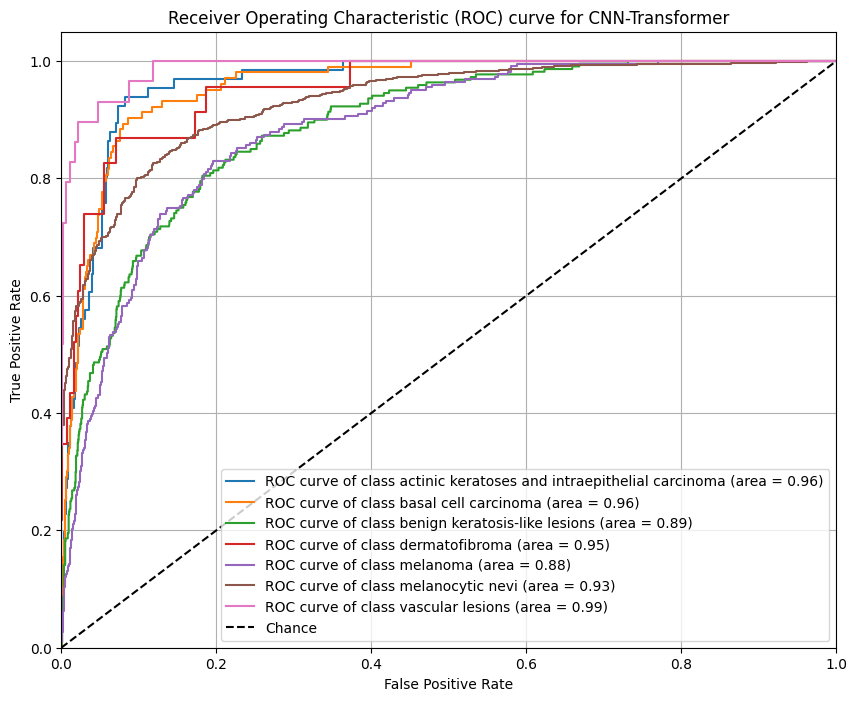

In [19]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

# Cargar el mejor modelo guardado
model_cnn_transformer.load_state_dict(torch.load('best_cnn_transformer_model.pth'))
model_cnn_transformer.eval() # Poner el modelo en modo evaluación

all_labels = []
all_preds = []

with torch.no_grad():
    for inputs, labels in test_loader_128:
        inputs = inputs.to(device)
        outputs = model_cnn_transformer(inputs)
        # Convertir log-probabilities a probabilidades
        probs = torch.nn.functional.softmax(outputs, dim=1)

        all_labels.extend(labels.squeeze().cpu().numpy())
        all_preds.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

# Binarizar las etiquetas para ROC de multiclass
num_classes = len(class_dict) # Obtenemos el número de clases del diccionario
b_all_labels = label_binarize(all_labels, classes=range(num_classes))

# Calcular la curva ROC y el AUC para cada clase
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(b_all_labels[:, i], all_preds[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Graficar las curvas ROC para cada clase
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {class_dict[str(i)]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance') # Curva de chance aleatorio
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) curve for CNN-Transformer')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
# ==========================================
# MÉTRICAS FINALES DEL CNN-TRANSFORMER (TEST)
# ==========================================
# Reutilizamos all_labels y all_preds calculados en la celda anterior (ROC).
# all_preds contiene las probabilidades (softmax); all_labels las etiquetas reales.
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report
)

# Clase predicha = la de mayor probabilidad
pred_classes = np.argmax(all_preds, axis=1)

# Métricas globales
acc_global = accuracy_score(all_labels, pred_classes)
macro_f1   = f1_score(all_labels, pred_classes, average='macro', zero_division=0)
macro_prec = precision_score(all_labels, pred_classes, average='macro', zero_division=0)
auc_ovr    = roc_auc_score(all_labels, all_preds, multi_class='ovr', average='macro')

# Recall específico para Melanoma (clase 4)
MELANOMA_CLASS = 4
recall_melanoma = recall_score(
    all_labels, pred_classes,
    labels=[MELANOMA_CLASS], average='macro', zero_division=0
)

print('-' * 50)
print('  RESULTADOS FINALES DEL CNN-TRANSFORMER (TEST)')
print('-' * 50)
print(f'Accuracy Global:        {acc_global:.4f}')
print(f'Macro F1-Score:         {macro_f1:.4f}')
print(f'Precisión (Macro):      {macro_prec:.4f}')
print(f'AUC-ROC (OVR Macro):    {auc_ovr:.4f}')
print(f'Recall (Melanoma):      {recall_melanoma:.4f}')
print('-' * 50)
print()
print('Reporte Detallado por Enfermedad:')
print(classification_report(all_labels, pred_classes, zero_division=0))